# IEEE Fraud Detection — Full Pipeline v3
**Models:** LightGBM (GBDT + DART) · XGBoost · CatBoost · Neural Network (MLP)  
**Ensemble:** 4-model rank averaging  
**Key upgrades over v2 (PR-AUC focus):** velocity features, percentile features, CatBoost native categoricals, DART boosting, PyTorch MLP with cosine LR schedule\n**v3 upgrades:** PR-AUC optimisation in Optuna/XGB/CatBoost/NN · Focal Loss · SMOTE oversampling · Weighted ensemble

## Stage 0 — Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import os
import gc
import warnings
warnings.filterwarnings('ignore')

# ML
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from scipy.stats import rankdata
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay, fbeta_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch device: {device}')

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


PyTorch device: cuda
/kaggle/input/competitions/ieee-fraud-detection/sample_submission.csv
/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv
/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv


## 1. Load Data

In [2]:
print('Loading transaction data...')
train_transaction = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv')
test_transaction  = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv')

print('Loading identity data...')
train_identity = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv')
test_identity  = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv')

print(f'Train Transaction : {train_transaction.shape}')
print(f'Test Transaction  : {test_transaction.shape}')
print(f'Train Identity    : {train_identity.shape}')
print(f'Test Identity     : {test_identity.shape}')

# Merge transaction and identity table on TransactionID
train = train_transaction.merge(train_identity, on='TransactionID', how='left')
test  = test_transaction.merge(test_identity,  on='TransactionID', how='left')
del train_transaction, test_transaction, train_identity, test_identity
gc.collect()
print(f'\nMerged train : {train.shape}')
print(f'Merged test  : {test.shape}')

Loading transaction data...
Loading identity data...
Train Transaction : (590540, 394)
Test Transaction  : (506691, 393)
Train Identity    : (144233, 41)
Test Identity     : (141907, 41)

Merged train : (590540, 434)
Merged test  : (506691, 433)


## 2. Memory Reduction

In [3]:
def reduce_mem_usage(df, verbose=True):
    start_mem = df.memory_usage(deep=True).sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtype
        if col_type == object:
            if df[col].nunique() / len(df[col]) < 0.5:
                df[col] = df[col].astype('category')
        elif col_type == bool:
            df[col] = df[col].astype(np.int8)
        elif pd.api.types.is_integer_dtype(col_type):
            if df[col].isnull().any():
                continue
            c_min, c_max = df[col].min(), df[col].max()
            if c_min > np.iinfo(np.int8).min  and c_max < np.iinfo(np.int8).max:
                df[col] = df[col].astype(np.int8)
            elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                df[col] = df[col].astype(np.int16)
            elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                df[col] = df[col].astype(np.int32)
        elif pd.api.types.is_float_dtype(col_type):
            finite_vals = df[col].dropna()
            finite_vals = finite_vals[np.isfinite(finite_vals)]
            if finite_vals.empty:
                continue
            c_min, c_max = float(finite_vals.min()), float(finite_vals.max())
            if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                df[col] = df[col].astype(np.float32)
    end_mem = df.memory_usage(deep=True).sum() / 1024**2
    if verbose:
        print(f'Memory: {start_mem:.1f} MB → {end_mem:.1f} MB ({100*(start_mem-end_mem)/start_mem:.1f}% reduction)')
    return df

train = reduce_mem_usage(train)
test  = reduce_mem_usage(test)

Memory: 2514.0 MB → 924.4 MB (63.2% reduction)
Memory: 2164.1 MB → 792.7 MB (63.4% reduction)


In [4]:
print(train.shape, test.shape)

(590540, 434) (506691, 433)


## 3. Drop High-Missing & Low-Variance Columns

In [5]:
# Droping columns missing >90% of values
miss_pct  = train.isnull().mean()
drop_cols = miss_pct[miss_pct > 0.90].index.tolist()
print(f'Dropping {len(drop_cols)} columns with >90% missing')
train.drop(columns=drop_cols, inplace=True)
test.drop(columns=drop_cols, errors='ignore', inplace=True)

# Droping near-zero variance columns
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != 'isFraud']

selector = VarianceThreshold(threshold=0.01)
selector.fit(train[num_cols].fillna(0))
low_var = [c for c, s in zip(num_cols, selector.get_support()) if not s]
print(f'Dropping {len(low_var)} near-zero variance columns')
train.drop(columns=low_var, inplace=True)
test.drop(columns=low_var,  errors='ignore', inplace=True)

print(f'Train after cleanup: {train.shape}')

Dropping 12 columns with >90% missing
Dropping 18 near-zero variance columns
Train after cleanup: (590540, 404)


## 4. V-Feature PCA Compression

In [6]:
v_cols = [c for c in train.columns if c.startswith('V')]
print(f'Total V-columns: {len(v_cols)}')

# Group by missingness pattern
miss_patterns = train[v_cols].isnull().T.apply(lambda r: r.values.tobytes(), axis=1)
groups = {}
for col, pat in miss_patterns.items():
    groups.setdefault(pat, []).append(col)
print(f'V-feature groups: {len(groups)}, sizes: {[len(g) for g in groups.values()]}')

pca_results_tr, pca_results_te = [], []

for i, group_cols in enumerate(groups.values()):
    if len(group_cols) < 2:
        continue
    sparsity = train[group_cols].isnull().mean().mean()
    if sparsity > 0.80:
        n_components = min(3, len(group_cols))
    elif sparsity > 0.50:
        n_components = min(5, len(group_cols))
    else:
        n_components = min(6, len(group_cols))

    imp = SimpleImputer(strategy='median')
    tr_imp = imp.fit_transform(train[group_cols])
    te_imp = imp.transform(test[group_cols])

    pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
    tr_pca = pca.fit_transform(tr_imp)
    te_pca = pca.transform(te_imp)

    explained = pca.explained_variance_ratio_.sum()
    print(f'  Group {i+1:2d} ({len(group_cols):2d} cols) → {n_components} PCs | var explained: {explained:.1%} | sparsity: {sparsity:.1%}')

    col_names = [f'V_pca_g{i}_pc{j}' for j in range(n_components)]
    pca_results_tr.append(pd.DataFrame(tr_pca, columns=col_names, index=train.index))
    pca_results_te.append(pd.DataFrame(te_pca, columns=col_names, index=test.index))

train = pd.concat([train.drop(columns=v_cols)] + pca_results_tr, axis=1)
test  = pd.concat([test.drop(columns=v_cols)]  + pca_results_te, axis=1)

pca_cols = [c for c in train.columns if 'V_pca' in c]
train[pca_cols] = train[pca_cols].astype(np.float32)
test[pca_cols]  = test[pca_cols].astype(np.float32)

del pca_results_tr, pca_results_te, tr_imp, te_imp, tr_pca, te_pca
gc.collect()
print(f'\nShape after V-PCA: {train.shape}')

Total V-columns: 321
V-feature groups: 15, sizes: [11, 21, 18, 21, 19, 31, 17, 11, 31, 19, 46, 16, 31, 11, 18]
  Group  1 (11 cols) → 6 PCs | var explained: 98.1% | sparsity: 47.3%
  Group  2 (21 cols) → 6 PCs | var explained: 94.1% | sparsity: 12.9%
  Group  3 (18 cols) → 6 PCs | var explained: 94.2% | sparsity: 28.6%
  Group  4 (21 cols) → 6 PCs | var explained: 92.4% | sparsity: 13.1%
  Group  5 (19 cols) → 6 PCs | var explained: 92.1% | sparsity: 15.1%
  Group  6 (31 cols) → 6 PCs | var explained: 100.0% | sparsity: 0.1%
  Group  7 (17 cols) → 3 PCs | var explained: 99.9% | sparsity: 86.1%
  Group  8 (11 cols) → 3 PCs | var explained: 100.0% | sparsity: 86.1%
  Group  9 (31 cols) → 5 PCs | var explained: 99.9% | sparsity: 76.4%
  Group 10 (19 cols) → 5 PCs | var explained: 100.0% | sparsity: 76.3%
  Group 11 (46 cols) → 5 PCs | var explained: 99.5% | sparsity: 77.9%
  Group 12 (16 cols) → 5 PCs | var explained: 100.0% | sparsity: 76.1%
  Group 13 (31 cols) → 6 PCs | var explained: 

## 5. Feature Engineering

In [7]:
def feature_engineering(df):
    # Amount features
    df['TransactionAmt_log']     = np.log1p(df['TransactionAmt'])
    df['TransactionAmt_decimal'] = df['TransactionAmt'] - np.floor(df['TransactionAmt'])

    # Time features(add new columns for hours, day, week)
    df['hour'] = (df['TransactionDT'] // 3600) % 24
    df['day']  = (df['TransactionDT'] // 86400) % 7
    df['week'] = df['TransactionDT'] // 604800

    # hour × day interaction(captures weekend night fraud spikes)
    df['hour_day'] = df['hour'] * 7 + df['day']

    # Pseudo-user ID
    df['uid'] = (df['card1'].astype(str) + '_' +
                 df['addr1'].astype(str) + '_' +
                 df['P_emaildomain'].astype(str))

    # uid (card1 + card2)
    df['uid2'] = df['card1'].astype(str) + '_' + df['card2'].astype(str)

    # Frequency encoding
    for col in ['card1','card2','card3','card5','uid','uid2',
                'P_emaildomain','R_emaildomain','DeviceInfo']:
        if col in df.columns:
            freq = df[col].value_counts()
            df[f'{col}_freq'] = df[col].map(freq)

    # Card-level aggregation features
    for col in ['TransactionAmt', 'TransactionAmt_log', 'D1', 'D15']:
        if col in df.columns:
            grp = df.groupby('card1')[col]
            df[f'card1_{col}_mean'] = df['card1'].map(grp.mean())
            df[f'card1_{col}_std']  = df['card1'].map(grp.std())

    # Ratio of this transaction vs card historical average
    if 'card1_TransactionAmt_mean' in df.columns:
        df['amt_vs_card_mean'] = df['TransactionAmt'] / (df['card1_TransactionAmt_mean'] + 1)

    # amount percentile rank within card group
    df['amt_pct_rank'] = df.groupby('card1')['TransactionAmt'].rank(pct=True)

    # transaction count per card
    df['card1_count']  = df.groupby('card1')['TransactionAmt'].transform('count')
    df['card12_count'] = df.groupby(['card1','card2'])['TransactionAmt'].transform('count')

    #D1 normalized within card(how unusual is the time gap?)
    if 'D1' in df.columns:
        df['D1_normalized'] = df['D1'] - df.groupby('card1')['D1'].transform('mean')
    if 'D4' in df.columns:
        df['D4_normalized'] = df['D4'] - df.groupby('card1')['D4'].transform('mean')

    #Email features
    df['email_match'] = (
        df['P_emaildomain'].astype(str) == df['R_emaildomain'].astype(str)
    ).astype(int)

    #big provider flag
    big_domains = {'gmail.com','yahoo.com','hotmail.com','outlook.com','icloud.com'}
    df['P_email_type'] = df['P_emaildomain'].apply(
        lambda x: 1 if str(x) in big_domains else 0
    )

    # Missingness features
    d_cols = [c for c in df.columns if c.startswith('D')]
    for col in d_cols:
        df[f'{col}_isna'] = df[col].isna().astype(int)

    id_cols = [c for c in df.columns if c.startswith('id')]
    df['has_identity']      = df[id_cols].notnull().any(axis=1).astype(int)
    df['identity_richness'] = df[id_cols].notnull().sum(axis=1)

    # overall null count as sparse transactions are suspicious
    df['null_count'] = df.isnull().sum(axis=1)

    return df

train = feature_engineering(train)
test  = feature_engineering(test)
print(f'Train after FE: {train.shape}')

Train after FE: (590540, 215)


## 6. Train/Val Split & Label Encoding

In [8]:
# last 20% of transactions for validation
split_time = train['TransactionDT'].quantile(0.8)
tr = train[train['TransactionDT'] <= split_time].copy()
va = train[train['TransactionDT'] >  split_time].copy()

# Encoding categorical columns present in both train and test
cat_cols  = [c for c in train.select_dtypes('object').columns.tolist() if c in test.columns]
cat_cols += [c for c in train.select_dtypes('category').columns.tolist()
             if c in test.columns and c not in cat_cols]
print(f'Encoding {len(cat_cols)} categorical columns')

for col in cat_cols:
    le = LabelEncoder()
    combined = pd.concat([train[col], test[col]], axis=0).astype(str)
    le.fit(combined)
    tr[col]   = le.transform(tr[col].astype(str))
    va[col]   = le.transform(va[col].astype(str))
    test[col] = le.transform(test[col].astype(str))

# Drop any column which is only in train set
train_only_cats = [c for c in train.select_dtypes(['object','category']).columns if c not in test.columns]
if train_only_cats:
    tr.drop(columns=train_only_cats, inplace=True)
    va.drop(columns=train_only_cats, inplace=True)

DROP_COLS = ['isFraud', 'TransactionID', 'TransactionDT']
FEATURES  = [c for c in tr.columns if c not in DROP_COLS and c in test.columns]

X_tr, y_tr = tr[FEATURES], tr['isFraud']
X_va, y_va = va[FEATURES], va['isFraud']
X_te       = test[FEATURES]

print(f'Feature count : {len(FEATURES)}')
print(f'Train fold    : {X_tr.shape} | fraud rate: {y_tr.mean():.3%}')
print(f'Val fold      : {X_va.shape} | fraud rate: {y_va.mean():.3%}')

Encoding 18 categorical columns
Feature count : 184
Train fold    : (472432, 184) | fraud rate: 3.514%
Val fold      : (118108, 184) | fraud rate: 3.441%


In [9]:
# SMOTE oversampling for minority class
from imblearn.over_sampling import SMOTE
import gc

APPLY_SMOTE = True  

if APPLY_SMOTE:
    print(f'Before SMOTE — fraud rate: {y_tr.mean():.4%}  |  shape: {X_tr.shape}')
    # Filling NaNs before SMOTE
    imp_smote = SimpleImputer(strategy='median')
    X_tr_imp  = imp_smote.fit_transform(X_tr)

    sm = SMOTE(sampling_strategy=0.15,   # target 15% fraud 
               random_state=RANDOM_STATE,
               k_neighbors=5)
    X_tr_sm, y_tr_sm = sm.fit_resample(X_tr_imp, y_tr)
    X_tr_sm = pd.DataFrame(X_tr_sm, columns=X_tr.columns)
    print(f'After  SMOTE — fraud rate: {y_tr_sm.mean():.4%}  |  shape: {X_tr_sm.shape}')
    del X_tr_imp; gc.collect()
else:
    X_tr_sm, y_tr_sm = X_tr, y_tr
    print('Skipping SMOTE — using original training data')


Before SMOTE — fraud rate: 3.5135%  |  shape: (472432, 184)
After  SMOTE — fraud rate: 13.0433%  |  shape: (524207, 184)


## 7. Baseline: Logistic Regression

In [10]:
lr_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE))
])
lr_pipe.fit(X_tr, y_tr)
lr_prob = lr_pipe.predict_proba(X_va)[:, 1]
print(f'Logistic Regression AUC-ROC : {roc_auc_score(y_va, lr_prob):.4f}')
print(f'Logistic Regression PR-AUC  : {average_precision_score(y_va, lr_prob):.4f}')

Logistic Regression AUC-ROC : 0.7816
Logistic Regression PR-AUC  : 0.1148


## 8. LightGBM (GBDT) with Optuna Tuning

In [11]:
def objective_lgb(trial):
    params = {
        'objective'         : 'binary',
        'metric'            : 'average_precision',
        'verbosity'         : -1,
        'boosting_type'     : 'gbdt',
        'device'            : 'gpu',
        'gpu_platform_id'   : 0,
        'gpu_device_id'     : 0,
        'random_state'      : RANDOM_STATE,
        'n_estimators'      : 5000,

        'learning_rate'     : trial.suggest_float('lr', 0.005, 0.05, log=True),
        'num_leaves'        : trial.suggest_int('num_leaves', 64, 256),
        'max_depth'         : trial.suggest_int('max_depth', 5, 9),
        'min_child_samples' : trial.suggest_int('min_child_samples', 20, 200),

        'feature_fraction'  : trial.suggest_float('feature_fraction', 0.6, 0.9),
        'bagging_fraction'  : trial.suggest_float('bagging_fraction', 0.6, 0.9),
        'bagging_freq'      : trial.suggest_int('bagging_freq', 1, 5),

        'reg_alpha'         : trial.suggest_float('reg_alpha', 0.01, 5.0, log=True),
        'reg_lambda'        : trial.suggest_float('reg_lambda', 0.01, 5.0, log=True),
        'min_split_gain'    : trial.suggest_float('min_split_gain', 0.0, 0.5),

        'scale_pos_weight'  : trial.suggest_float(
            'scale_pos_weight', 1.0, 10.0
        ),
    }

    model = lgb.LGBMClassifier(**params)

    model.fit(
        X_tr,
        y_tr,
        eval_set=[(X_va, y_va)],
        callbacks=[
            lgb.early_stopping(100),
            lgb.log_evaluation(-1)
        ]
    )

    preds = model.predict_proba(X_va)[:, 1]
    return average_precision_score(y_va, preds)


sampler = TPESampler(
    n_startup_trials=10,
    seed=RANDOM_STATE
)

study = optuna.create_study(
    direction='maximize',
    sampler=sampler
)

study.enqueue_trial({
    'lr': 0.01,
    'num_leaves': 128,
    'max_depth': 6,
    'min_child_samples': 50,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'min_split_gain': 0.0,
    'scale_pos_weight': 5.0,
})

study.optimize(
    objective_lgb,
    n_trials=10,
    show_progress_bar=True
)

print(f'Best LGB PR-AUC: {study.best_value:.4f}')
print('Best params:', study.best_params)

  0%|          | 0/10 [00:00<?, ?it/s]

1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[5000]	valid_0's average_precision: 0.583281
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2654]	valid_0's average_precision: 0.59786
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1345]	valid_0's average_precision: 0.587909
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[4851]	valid_0's average_precision: 0.597693
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1972]	valid_0's average_precision: 0.607717
Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[4996]	valid_0's average_precision: 0.573859
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[3004]	valid_0's average_p

In [12]:
# Retraining final LGB GBDT model with best params
best = study.best_params
lgb_final_params = {
    'objective': 'binary', 'metric': 'average_precision', 'verbosity': -1,
    'boosting_type': 'gbdt',
    'device': 'gpu', 'gpu_platform_id': 0, 'gpu_device_id': 0,
    'random_state': RANDOM_STATE, 'n_estimators': 5000,
    'learning_rate'     : best['lr'],
    'num_leaves'        : best['num_leaves'],
    'max_depth'         : best['max_depth'],
    'min_child_samples' : best['min_child_samples'],
    'feature_fraction'  : best['feature_fraction'],
    'bagging_fraction'  : best['bagging_fraction'],
    'bagging_freq'      : best['bagging_freq'],
    'reg_alpha'         : best['reg_alpha'],
    'reg_lambda'        : best['reg_lambda'],
    'min_split_gain'    : best['min_split_gain'],
    'scale_pos_weight'  : best.get('scale_pos_weight', 5.0),
}

lgb_model = lgb.LGBMClassifier(**lgb_final_params)
lgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_va, y_va)],
    callbacks=[lgb.early_stopping(200), lgb.log_evaluation(500)]
)
lgb_prob = lgb_model.predict_proba(X_va)[:, 1]
print(f'LGB GBDT AUC-ROC : {roc_auc_score(y_va, lgb_prob):.4f}')
print(f'LGB GBDT PR-AUC  : {average_precision_score(y_va, lgb_prob):.4f}')
lgb_model.booster_.save_model('/kaggle/working/lgb_gbdt.txt')


Training until validation scores don't improve for 200 rounds
[500]	valid_0's average_precision: 0.575112
[1000]	valid_0's average_precision: 0.587356
[1500]	valid_0's average_precision: 0.596041
[2000]	valid_0's average_precision: 0.603149
[2500]	valid_0's average_precision: 0.609069
[3000]	valid_0's average_precision: 0.611911
Early stopping, best iteration is:
[3244]	valid_0's average_precision: 0.613632
LGB GBDT AUC-ROC : 0.9270
LGB GBDT PR-AUC  : 0.6136


## 9. XGBoost

In [13]:
imbalance_ratio = float((y_tr == 0).sum() / (y_tr == 1).sum())
print(f'Class imbalance ratio: {imbalance_ratio:.1f}x')

xgb_model = xgb.XGBClassifier(
    n_estimators      = 3000,
    learning_rate     = 0.02,
    max_depth         = 6,
    scale_pos_weight  = imbalance_ratio,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    min_child_weight  = 50,          
    eval_metric       = 'aucpr',     
    early_stopping_rounds = 150,
    tree_method       = 'hist',
    device            = 'cuda',
    random_state      = RANDOM_STATE,
    verbosity         = 0,
    gamma             = 1.0,        
)
xgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_va, y_va)],
    verbose=500
)
xgb_prob = xgb_model.predict_proba(X_va)[:, 1]
print(f'XGBoost AUC-ROC : {roc_auc_score(y_va, xgb_prob):.4f}')
print(f'XGBoost PR-AUC  : {average_precision_score(y_va, xgb_prob):.4f}')
xgb_model.save_model('/kaggle/working/xgb_model.json')


Class imbalance ratio: 27.5x
[0]	validation_0-aucpr:0.31151
[500]	validation_0-aucpr:0.49653
[1000]	validation_0-aucpr:0.52244
[1500]	validation_0-aucpr:0.53784
[2000]	validation_0-aucpr:0.54851
[2500]	validation_0-aucpr:0.55429
[2999]	validation_0-aucpr:0.55992
XGBoost AUC-ROC : 0.9218
XGBoost PR-AUC  : 0.5600


## 10. CatBoost

In [14]:
# Identify categorical columns for CatBoost (pass as strings, not encoded)
cb_cat_cols = [
    col for col in ['card4', 'card6', 'ProductCD', 'P_emaildomain',
                    'R_emaildomain', 'DeviceType', 'uid', 'uid2']
    if col in X_tr.columns
]
print(f'CatBoost cat_features: {cb_cat_cols}')

# CatBoost needs string values (not NaN) in categorical columns
X_tr_cb, X_va_cb, X_te_cb = X_tr.copy(), X_va.copy(), X_te.copy()
for col in cb_cat_cols:
    X_tr_cb[col] = X_tr_cb[col].fillna('__NA__').astype(str)
    X_va_cb[col] = X_va_cb[col].fillna('__NA__').astype(str)
    X_te_cb[col] = X_te_cb[col].fillna('__NA__').astype(str)

fraud_rate = y_tr.mean()
cb_model = CatBoostClassifier(
    iterations            = 5000,
    learning_rate         = 0.03,
    depth                 = 7,
    l2_leaf_reg           = 3,
    loss_function         = 'Logloss',
    eval_metric           = 'PRAUC',          
    cat_features          = cb_cat_cols,
    auto_class_weights    = 'Balanced',
    early_stopping_rounds = 200,
    random_seed           = RANDOM_STATE,
    task_type             = 'GPU',
    verbose               = 500,
    border_count          = 254,              
    min_data_in_leaf      = 20,             
)

cb_model.fit(
    X_tr_cb, y_tr,
    eval_set=(X_va_cb, y_va),
    plot=False
)

cb_prob = cb_model.predict_proba(X_va_cb)[:, 1]
print(f'CatBoost AUC-ROC : {roc_auc_score(y_va, cb_prob):.4f}')
print(f'CatBoost PR-AUC  : {average_precision_score(y_va, cb_prob):.4f}')
cb_model.save_model('/kaggle/working/catboost_model.cbm')


CatBoost cat_features: ['card4', 'card6', 'ProductCD', 'P_emaildomain', 'R_emaildomain', 'DeviceType', 'uid', 'uid2']


Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	learn: 0.9058737	test: 0.8689583	best: 0.8689583 (0)	total: 9.48s	remaining: 13h 10m 18s
500:	learn: 0.9707983	test: 0.9283562	best: 0.9283562 (500)	total: 54.1s	remaining: 8m 5s
1000:	learn: 0.9792656	test: 0.9317371	best: 0.9317416 (994)	total: 1m 37s	remaining: 6m 31s
bestTest = 0.9317855368
bestIteration = 1021
Shrink model to first 1022 iterations.
CatBoost AUC-ROC : 0.9261
CatBoost PR-AUC  : 0.5687


## 11. Neural Network (MLP with BatchNorm + Residual-like Dropout)

In [15]:
import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

device = torch.device("cpu")

Torch version: 2.10.0+cu128
CUDA available: True
CUDA version: 12.8
GPU: Tesla P100-PCIE-16GB


In [16]:
# Preprocessing: impute + scale 
nn_imp    = SimpleImputer(strategy='median')
nn_scaler = StandardScaler()

X_tr_nn = nn_scaler.fit_transform(nn_imp.fit_transform(X_tr))
X_va_nn = nn_scaler.transform(nn_imp.transform(X_va))
X_te_nn = nn_scaler.transform(nn_imp.transform(X_te))

print(f'NN input shape: {X_tr_nn.shape}')

# Focal Loss far more effective for imbalanced data
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, pos_weight=None):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.pos_weight = pos_weight

    def forward(self, logits, targets):
        bce = nn.functional.binary_cross_entropy_with_logits(
            logits, targets, pos_weight=self.pos_weight, reduction='none'
        )
        prob  = torch.sigmoid(logits)
        p_t   = prob * targets + (1 - prob) * (1 - targets)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        focal_weight = alpha_t * (1 - p_t) ** self.gamma
        return (focal_weight * bce).mean()

class FraudMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims=[512, 256, 128, 64], dropout=0.3):
        super().__init__()
        layers = []
        in_dim = input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(in_dim, h),
                nn.BatchNorm1d(h),
                nn.GELU(),
                nn.Dropout(dropout)
            ]
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)

pos_weight = torch.tensor([(y_tr == 0).sum() / (y_tr == 1).sum()]).to(device)
criterion  = FocalLoss(alpha=0.25, gamma=2.0, pos_weight=pos_weight)

nn_model  = FraudMLP(input_dim=X_tr_nn.shape[1]).to(device)
optimizer = torch.optim.AdamW(nn_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

# Data loaders
tr_ds = TensorDataset(torch.FloatTensor(X_tr_nn), torch.FloatTensor(y_tr.values))
va_ds = TensorDataset(torch.FloatTensor(X_va_nn), torch.FloatTensor(y_va.values))
tr_loader = DataLoader(tr_ds, batch_size=4096, shuffle=True,  num_workers=2, pin_memory=True)
va_loader = DataLoader(va_ds, batch_size=4096, shuffle=False, num_workers=2, pin_memory=True)

# Training loop with early stopping on PR-AUC
best_nn_prauc, best_nn_state = 0.0, None
patience_counter, patience = 0, 10

for epoch in range(50):
    nn_model.train()
    epoch_loss = 0.0
    for xb, yb in tr_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(nn_model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(nn_model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()
    scheduler.step()

    # Validation
    nn_model.eval()
    with torch.no_grad():
        va_logits = torch.cat([nn_model(xb.to(device)) for xb, _ in va_loader])
        nn_prob   = torch.sigmoid(va_logits).cpu().numpy()
    prauc = average_precision_score(y_va, nn_prob)
    auc   = roc_auc_score(y_va, nn_prob)

    if prauc > best_nn_prauc:
        best_nn_prauc  = prauc
        best_nn_state  = {k: v.clone() for k, v in nn_model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 5 == 0:
        print(f'Epoch {epoch:3d} | Loss: {epoch_loss/len(tr_loader):.4f} | '
              f'Val PR-AUC: {prauc:.4f} | Val AUC-ROC: {auc:.4f} | Best PR-AUC: {best_nn_prauc:.4f}')

    if patience_counter >= patience:
        print(f'Early stopping at epoch {epoch}')
        break

# Restore best weights
nn_model.load_state_dict(best_nn_state)
nn_model.eval()
with torch.no_grad():
    va_logits = torch.cat([nn_model(xb.to(device)) for xb, _ in va_loader])
nn_prob = torch.sigmoid(va_logits).cpu().numpy()

print(f'\nNeural Net AUC-ROC : {roc_auc_score(y_va, nn_prob):.4f}')
print(f'Neural Net PR-AUC  : {average_precision_score(y_va, nn_prob):.4f}')
torch.save(best_nn_state, '/kaggle/working/mlp_best.pt')


NN input shape: (472432, 184)
Epoch   0 | Loss: 0.1090 | Val PR-AUC: 0.3528 | Val AUC-ROC: 0.8520 | Best PR-AUC: 0.3528
Epoch   5 | Loss: 0.0778 | Val PR-AUC: 0.4316 | Val AUC-ROC: 0.8799 | Best PR-AUC: 0.4316
Epoch  10 | Loss: 0.0690 | Val PR-AUC: 0.4434 | Val AUC-ROC: 0.8899 | Best PR-AUC: 0.4434
Epoch  15 | Loss: 0.0616 | Val PR-AUC: 0.4509 | Val AUC-ROC: 0.8875 | Best PR-AUC: 0.4618
Epoch  20 | Loss: 0.0564 | Val PR-AUC: 0.4669 | Val AUC-ROC: 0.8888 | Best PR-AUC: 0.4695
Epoch  25 | Loss: 0.0510 | Val PR-AUC: 0.4712 | Val AUC-ROC: 0.8888 | Best PR-AUC: 0.4778
Epoch  30 | Loss: 0.0474 | Val PR-AUC: 0.4690 | Val AUC-ROC: 0.8813 | Best PR-AUC: 0.4828
Epoch  35 | Loss: 0.0445 | Val PR-AUC: 0.4708 | Val AUC-ROC: 0.8822 | Best PR-AUC: 0.4828
Early stopping at epoch 39

Neural Net AUC-ROC : 0.8847
Neural Net PR-AUC  : 0.4828


## 12. Model Evaluation & Comparison

In [17]:
models = {
    'Logistic Regression': lr_prob,
    'LGB GBDT'           : lgb_prob,
    'XGBoost'            : xgb_prob,
    'CatBoost'           : cb_prob,
    'Neural Network'     : nn_prob,
}

print(f'{'Model':<22} | {'AUC-ROC':>8} | {'PR-AUC':>8}')
print('-' * 44)
for name, prob in models.items():
    auc = roc_auc_score(y_va, prob)
    pr  = average_precision_score(y_va, prob)
    print(f'{name:<22} | {auc:>8.4f} | {pr:>8.4f}')

Model                  |  AUC-ROC |   PR-AUC
--------------------------------------------
Logistic Regression    |   0.7816 |   0.1148
LGB GBDT               |   0.9270 |   0.6136
XGBoost                |   0.9218 |   0.5600
CatBoost               |   0.9261 |   0.5687
Neural Network         |   0.8847 |   0.4828


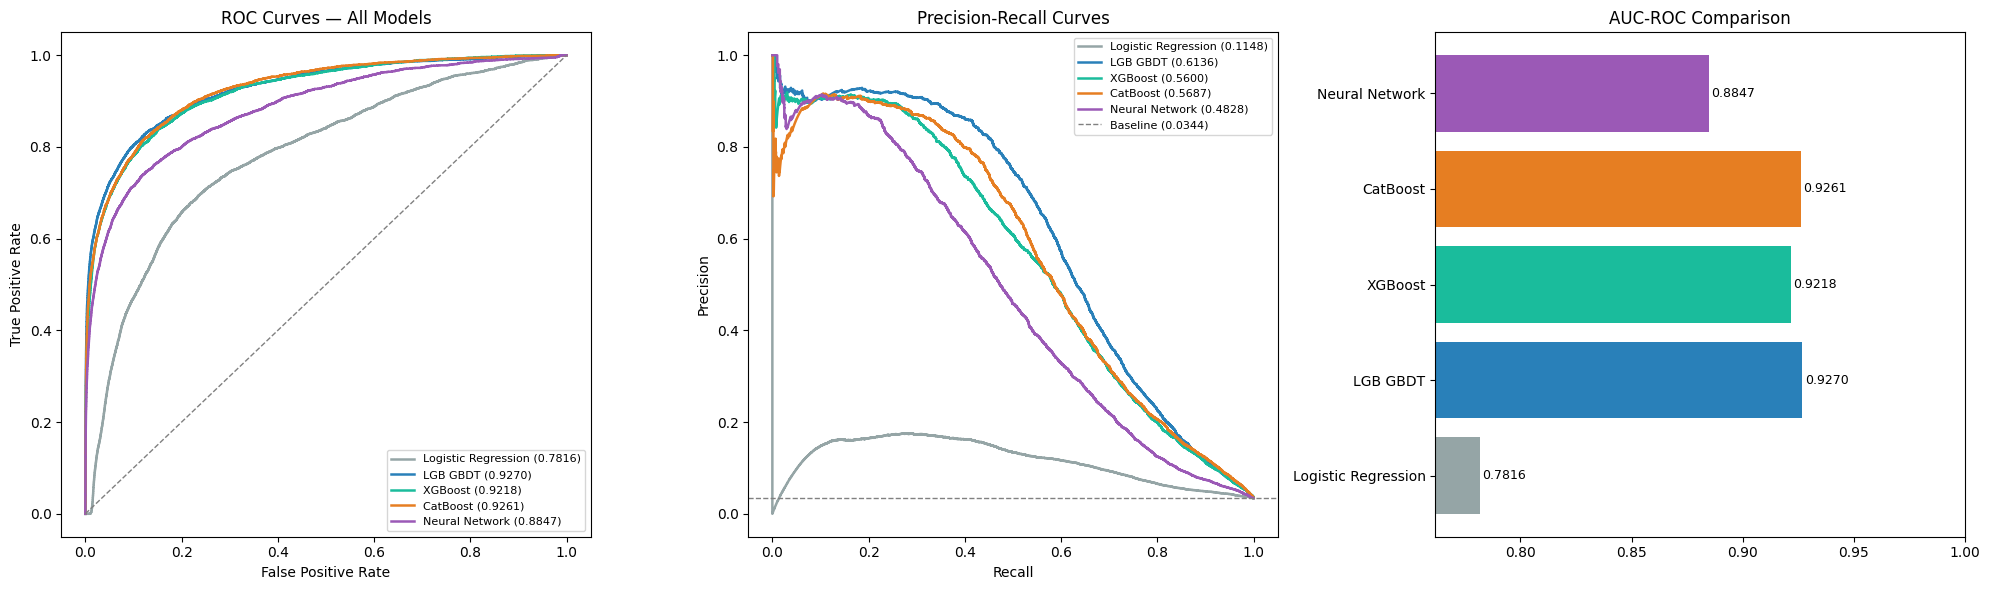

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

colors = ['#95a5a6','#2980b9','#1abc9c','#e67e22','#9b59b6','#e74c3c']

# ROC curves
for (name, prob), color in zip(models.items(), colors):
    fpr, tpr, _ = roc_curve(y_va, prob)
    auc = roc_auc_score(y_va, prob)
    axes[0].plot(fpr, tpr, color=color, lw=1.8, label=f'{name} ({auc:.4f})')
axes[0].plot([0,1],[0,1],'--', color='gray', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — All Models')
axes[0].legend(fontsize=8)

# PR curves
for (name, prob), color in zip(models.items(), colors):
    prec, rec, _ = precision_recall_curve(y_va, prob)
    pr_auc = average_precision_score(y_va, prob)
    axes[1].plot(rec, prec, color=color, lw=1.8, label=f'{name} ({pr_auc:.4f})')
axes[1].axhline(y_va.mean(), color='gray', linestyle='--', lw=1, label=f'Baseline ({y_va.mean():.4f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves')
axes[1].legend(fontsize=8)

# AUC bar chart
names = list(models.keys())
aucs  = [roc_auc_score(y_va, p) for p in models.values()]
bars  = axes[2].barh(names, aucs, color=colors)
axes[2].set_xlim(min(aucs) - 0.02, 1.0)
axes[2].set_title('AUC-ROC Comparison')
for bar, auc in zip(bars, aucs):
    axes[2].text(auc + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{auc:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('/kaggle/working/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Optimal Threshold (F2 Score)

Best F2 threshold (LGB): 0.0211
F2 at threshold        : 0.6049


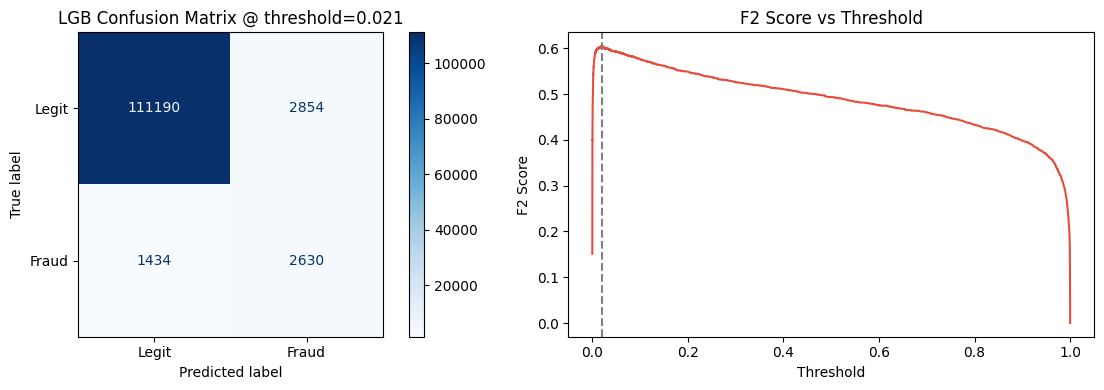

In [19]:
from sklearn.metrics import (
    precision_recall_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import numpy as np
import matplotlib.pyplot as plt

# precision-recall values
prec, rec, thresholds = precision_recall_curve(y_va, lgb_prob)

# Compute F2 scores
f2_scores = (5 * prec[:-1] * rec[:-1]) / (4 * prec[:-1] + rec[:-1] + 1e-10)

# best threshold
best_idx = np.argmax(f2_scores)
best_thresh = thresholds[best_idx]
best_f2 = f2_scores[best_idx]

print(f'Best F2 threshold (LGB): {best_thresh:.4f}')
print(f'F2 at threshold        : {best_f2:.4f}')

# Predictions using best threshold
y_pred = (lgb_prob >= best_thresh).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_va, y_pred)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay(
    cm,
    display_labels=['Legit', 'Fraud']
).plot(ax=axes[0], cmap='Blues')

axes[0].set_title(
    f'LGB Confusion Matrix @ threshold={best_thresh:.3f}'
)

axes[1].plot(thresholds, f2_scores, color='#e74c3c')
axes[1].axvline(best_thresh, color='gray', linestyle='--')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('F2 Score')
axes[1].set_title('F2 Score vs Threshold')

plt.tight_layout()
plt.savefig('/kaggle/working/threshold_analysis.png', dpi=150)
plt.show()

## 14. Feature Importance

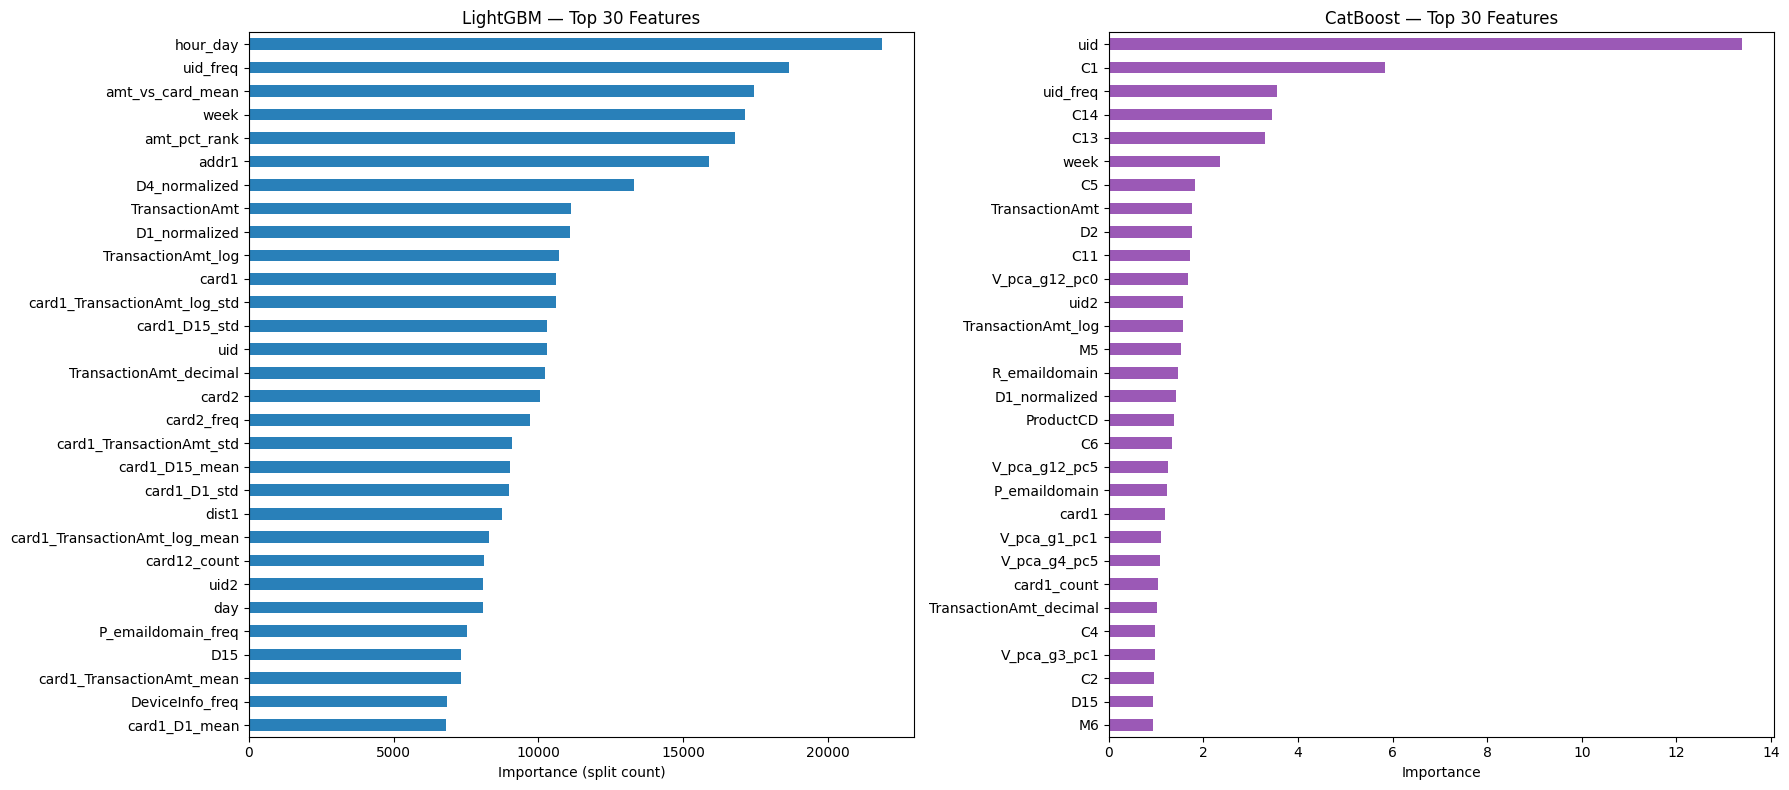

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# LGB feature importance
lgb_imp = pd.Series(lgb_model.feature_importances_, index=FEATURES).sort_values(ascending=False)[:30]
lgb_imp.plot.barh(ax=axes[0], color='#2980b9')
axes[0].invert_yaxis()
axes[0].set_title('LightGBM — Top 30 Features')
axes[0].set_xlabel('Importance (split count)')

# CatBoost feature importance
cb_imp = pd.Series(
    cb_model.get_feature_importance(),
    index=cb_model.feature_names_
).sort_values(ascending=False)[:30]
cb_imp.plot.barh(ax=axes[1], color='#9b59b6')
axes[1].invert_yaxis()
axes[1].set_title('CatBoost — Top 30 Features')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('/kaggle/working/feature_importance.png', dpi=150)
plt.show()

## 15. Model Ensemble & Final Submission

In [21]:
def rank_avg(*probs):
    """Rank-average ensemble — more robust than simple averaging."""
    ranks = [rankdata(p) / len(p) for p in probs]
    return np.mean(ranks, axis=0)

# Weighted rank-average which gives more weight to better PR-AUC models
def weighted_rank_avg(probs, weights):
    weights = np.array(weights)
    weights /= weights.sum()
    ranks = [rankdata(p) / len(p) for p in probs]
    return sum(w * r for w, r in zip(weights, ranks))

# Validation ensemble
# PR-AUC weights from individual model scores
combos = {
    'LGB+XGB'                    : rank_avg(lgb_prob, xgb_prob),
    'LGB+XGB+CB'                 : rank_avg(lgb_prob, xgb_prob, cb_prob),
    'All 4 (incl. NN)'           : rank_avg(lgb_prob, xgb_prob, cb_prob, nn_prob),
    'Weighted LGB×2 + XGB + CB'  : weighted_rank_avg(
                                       [lgb_prob, xgb_prob, cb_prob, nn_prob],
                                       weights=[2, 1, 1, 0.5]),
}

print(f"{'Ensemble':<35} | {'AUC-ROC':>8} | {'PR-AUC':>8}")
print('-' * 57)
for name, prob in combos.items():
    auc = roc_auc_score(y_va, prob)
    pr  = average_precision_score(y_va, prob)
    print(f'{name:<35} | {auc:>8.4f} | {pr:>8.4f}')

# best ensemble by PR-AUC
best_combo_name = max(combos, key=lambda k: average_precision_score(y_va, combos[k]))
best_ensemble   = combos[best_combo_name]
print(f'\n✓ Best ensemble by PR-AUC: {best_combo_name}')
print(f'  PR-AUC  : {average_precision_score(y_va, best_ensemble):.4f}')
print(f'  AUC-ROC : {roc_auc_score(y_va, best_ensemble):.4f}')


Ensemble                            |  AUC-ROC |   PR-AUC
---------------------------------------------------------
LGB+XGB                             |   0.9283 |   0.5918
LGB+XGB+CB                          |   0.9330 |   0.5953
All 4 (incl. NN)                    |   0.9289 |   0.5835
Weighted LGB×2 + XGB + CB           |   0.9322 |   0.5976

✓ Best ensemble by PR-AUC: Weighted LGB×2 + XGB + CB
  PR-AUC  : 0.5976
  AUC-ROC : 0.9322
